# Step 3: Data Augmentation

用 new_features（224 筆）訓練，對 hist_features（10487 筆）推估 BASS 參數（p、q、M、constant）。

- **方法 A**：KMeans Clustering（k=10）
- **方法 B**：KNN 距離加權（K=5）

以 test set（20%）的 MAE / RMSE 決定最終使用方法。

## 設計說明：為何最終改用 KNN

開發過程中曾嘗試兩種分群方法，最終皆放棄，改用 KNN 作為唯一推估方式：

**方法 A-1：KMeans Clustering**
用 embedding + duration + AI業配判定 + best_topic_labels 做分群，以 cluster 平均值推估。問題：training data 只有 178 筆，k=20 時平均每群僅 9 筆；k=8 時 cluster 內部仍有極端值，M 值出現 1.676e+25 等不合理數字，即使加 log1p 轉換仍有分群不均問題。

**方法 A-2：Topic Median**
改用 best_topic_labels 直接分群取中位數。問題：部分 topic 在 train 只有 1～2 筆，缺乏代表性；hist_features 有些 topic 在 train 未出現，只能 fallback 到全體中位數，損失個別差異。

**最終選用 KNN（K=5）**
不需預先定義群數，直接找語意最相近的 5 筆訓練資料做 Euclidean 距離加權平均，保留個別差異且不受分群粒度影響，RMSE 表現穩定優於上述方法。

In [111]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [112]:
PROCESSED = Path('../data/processed')
OUTPUT    = Path('../data/output')
OUTPUT.mkdir(parents=True, exist_ok=True)

new_features  = pd.read_csv(PROCESSED / 'new_features.csv')
hist_features = pd.read_csv(PROCESSED / 'hist_features.csv')

print('new_features :', new_features.shape)
print('hist_features:', hist_features.shape)

new_features : (224, 1084)
hist_features: (10375, 1083)


/var/folders/qg/p6lmk9491pd3rdlzsf84mfrh0000gn/T/ipykernel_26361/1585845337.py:6: DtypeWarning: Columns (0: 資料抓取時間, 1: 發文時間, 2: 前10則熱門留言, 3: 完整文案, 4: AI業配判定, 5: 品牌名稱, 6: 產品類型, 7: 業配類型) have mixed types. Specify dtype option on import or set low_memory=False.
  hist_features = pd.read_csv(PROCESSED / 'hist_features.csv')


## 1. 定義特徵欄位與資料切分

In [113]:
emb_cols    = [f'emb_new_{i:03d}' for i in range(1024)]
target_cols = ['p_after4d', 'q_after4d', 'M_after4d', 'constant_after4d_time0_views']
out_cols    = ['p', 'q', 'M', 'constant']

# 只保留四個 target 都不為空的樣本，並做 log1p 壓縮極端值
labeled = new_features.dropna(subset=target_cols).reset_index(drop=True)
labeled[target_cols] = labeled[target_cols].apply(np.log1p)

train_df, test_df = train_test_split(labeled, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'labeled: {len(labeled)} 筆')
print(f'train  : {len(train_df)} 筆')
print(f'test   : {len(test_df)} 筆')

labeled: 224 筆
train  : 179 筆
test   : 45 筆


In [114]:
# LabelEncoder：fit 在三個資料集的聯集上，確保 hist/test 不會出現 unseen label
le = LabelEncoder()
all_labels = list(
    pd.concat([train_df['best_topic_labels'],
               test_df['best_topic_labels'],
               hist_features['best_topic_labels']])
    .dropna().unique()
) + ['unknown']
le.fit(all_labels)

num_extra = ['duration', 'AI業配判定']

def build_raw(df):
    d = df[emb_cols + num_extra].copy()
    d['best_topic_labels_enc'] = le.transform(
        df['best_topic_labels'].fillna('unknown')
    )
    return d

# 中位數和 StandardScaler 只在 train 上 fit（避免 leakage）
train_raw = build_raw(train_df)
medians   = train_raw.median()

scaler = StandardScaler()
scaler.fit(train_raw.fillna(medians))

def get_X(df):
    d = build_raw(df).fillna(medians)
    return scaler.transform(d)

X_train = get_X(train_df)
print(f'特徵維度：{X_train.shape[1]}  '
      f'（emb_new×1024 + duration + AI業配判定 + best_topic_labels_enc）')

特徵維度：1027  （emb_new×1024 + duration + AI業配判定 + best_topic_labels_enc）


In [115]:
# 診斷：StandardScaler 後各特徵的 mean 和 std（應接近 0 和 1，異常值代表離群或 scale 問題）
feat_names = build_raw(train_df).columns.tolist()
feat_stats = pd.DataFrame({
    'mean': X_train.mean(axis=0),
    'std' : X_train.std(axis=0),
}, index=feat_names)
print('=== StandardScaler 後特徵統計 ===')
print(feat_stats.to_string())

=== StandardScaler 後特徵統計 ===
                               mean  std
emb_new_000            1.488567e-17  1.0
emb_new_001           -4.961891e-17  1.0
emb_new_002           -2.480945e-18  1.0
emb_new_003            0.000000e+00  1.0
emb_new_004            2.480945e-17  1.0
emb_new_005           -2.480945e-17  1.0
emb_new_006            5.954269e-17  1.0
emb_new_007           -1.984756e-17  1.0
emb_new_008           -7.939025e-17  1.0
emb_new_009           -2.977134e-17  1.0
emb_new_010            1.240473e-17  1.0
emb_new_011           -2.977134e-17  1.0
emb_new_012            6.698552e-17  1.0
emb_new_013            4.465702e-17  1.0
emb_new_014           -2.133613e-16  1.0
emb_new_015           -7.939025e-17  1.0
emb_new_016            5.954269e-17  1.0
emb_new_017            7.939025e-17  1.0
emb_new_018           -2.480945e-17  1.0
emb_new_019           -3.969512e-17  1.0
emb_new_020           -5.458080e-17  1.0
emb_new_021           -5.954269e-17  1.0
emb_new_022           -1.190

## 2. 方法：KNN 距離加權（K=5）——唯一採用方法

In [116]:
K_NEIGHBORS = 5

knn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean')
knn.fit(X_train)

def predict_knn(df):
    distances, idx = knn.kneighbors(get_X(df))
    weights = 1.0 / (distances + 1e-8)
    weights = weights / weights.sum(axis=1, keepdims=True)
    preds = {}
    for col in target_cols:
        neighbor_vals = train_df[col].values[idx]  # (n, K)
        preds[col]    = (weights * neighbor_vals).sum(axis=1)
    return pd.DataFrame(preds)

test_pred_b = predict_knn(test_df)
print('方法 B 預測範例（前 3 筆）:')
print(test_pred_b.head(3))

方法 B 預測範例（前 3 筆）:
   p_after4d  q_after4d  M_after4d  constant_after4d_time0_views
0   0.093760   0.016415   9.856178                      9.395433
1   0.094831   0.055479  11.141407                     10.736536
2   0.059500   0.175987   9.668322                      7.030666


## 4. 交叉驗證（Test Set 評估）

In [117]:
# target 已做 log1p，預測值也在 log scale，MAE/RMSE 直接在 log scale 下比較
rows = []
for col, label in zip(target_cols, out_cols):
    y = test_df[col].values
    rows.append({
        'target': label,
        'MAE'   : mean_absolute_error(y, test_pred_b[col]),
        'RMSE'  : np.sqrt(mean_squared_error(y, test_pred_b[col])),
    })

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
print(f'\nKNN RMSE 總和（log scale）：{eval_df["RMSE"].sum():.4f}')

  target      MAE      RMSE
       p 0.078363  0.091799
       q 0.100413  0.140260
       M 7.656432 26.394137
constant 1.263486  2.128959

KNN RMSE 總和（log scale）：28.7552


## 5. 選擇最佳方法並輸出 augmented_hist.csv

In [118]:
best_method  = 'KNN'
hist_pred_df = predict_knn(hist_features)

hist_pred_df = hist_pred_df.rename(columns=dict(zip(target_cols, out_cols)))

# log scale → 原始尺度
for col in out_cols:
    hist_pred_df[col] = np.expm1(hist_pred_df[col])

hist_pred_df.insert(0, 'reels_shortcode', hist_features['reels_shortcode'].values)
hist_pred_df['method_used'] = best_method

out_path = OUTPUT / 'augmented_hist.csv'
hist_pred_df.to_csv(out_path, index=False)
print(f'選用方法：{best_method}')
print(f'已儲存：{out_path}')
print(hist_pred_df.shape)
print(hist_pred_df.head())

選用方法：KNN
已儲存：../data/output/augmented_hist.csv
(10375, 6)
  reels_shortcode         p         q             M      constant method_used
0     DPeT4BHExo-  0.118798  0.053828  1.270806e+06  30791.232225         KNN
1     DPZEm_oExnd  0.118828  0.053800  1.271841e+06  30796.262142         KNN
2     DLvRZSlTBzn  0.118790  0.053834  1.270692e+06  30789.814759         KNN
3     DIvNtToTBL-  0.118790  0.053834  1.270687e+06  30789.826857         KNN
4     Ciksu1-vDBo  0.086489  0.061164  4.524175e+07  42295.860858         KNN


=== Test 前 3 筆的最近鄰分析 ===

【查詢筆 #0】
{'best_topic_labels': nan, 'duration': np.float64(43.745), 'AI業配判定': nan}
  鄰居：
  [1] dist=36.9576  {'best_topic_labels': nan, 'duration': np.float64(63.413), 'AI業配判定': nan}
  [2] dist=38.5931  {'best_topic_labels': nan, 'duration': np.float64(23.102), 'AI業配判定': nan}
  [3] dist=38.8660  {'best_topic_labels': nan, 'duration': np.float64(98.08), 'AI業配判定': nan}
  [4] dist=39.0125  {'best_topic_labels': nan, 'duration': np.float64(18.389), 'AI業配判定': nan}
  [5] dist=39.2706  {'best_topic_labels': nan, 'duration': np.float64(54.567), 'AI業配判定': nan}

【查詢筆 #1】
{'best_topic_labels': nan, 'duration': np.float64(116.133), 'AI業配判定': nan}
  鄰居：
  [1] dist=22.1714  {'best_topic_labels': nan, 'duration': np.float64(103.747), 'AI業配判定': nan}
  [2] dist=26.6982  {'best_topic_labels': nan, 'duration': np.float64(86.533), 'AI業配判定': nan}
  [3] dist=40.1636  {'best_topic_labels': nan, 'duration': np.float64(28.513), 'AI業配判定': nan}
  [4] dist=42.2409  {'best_topic_labels': 

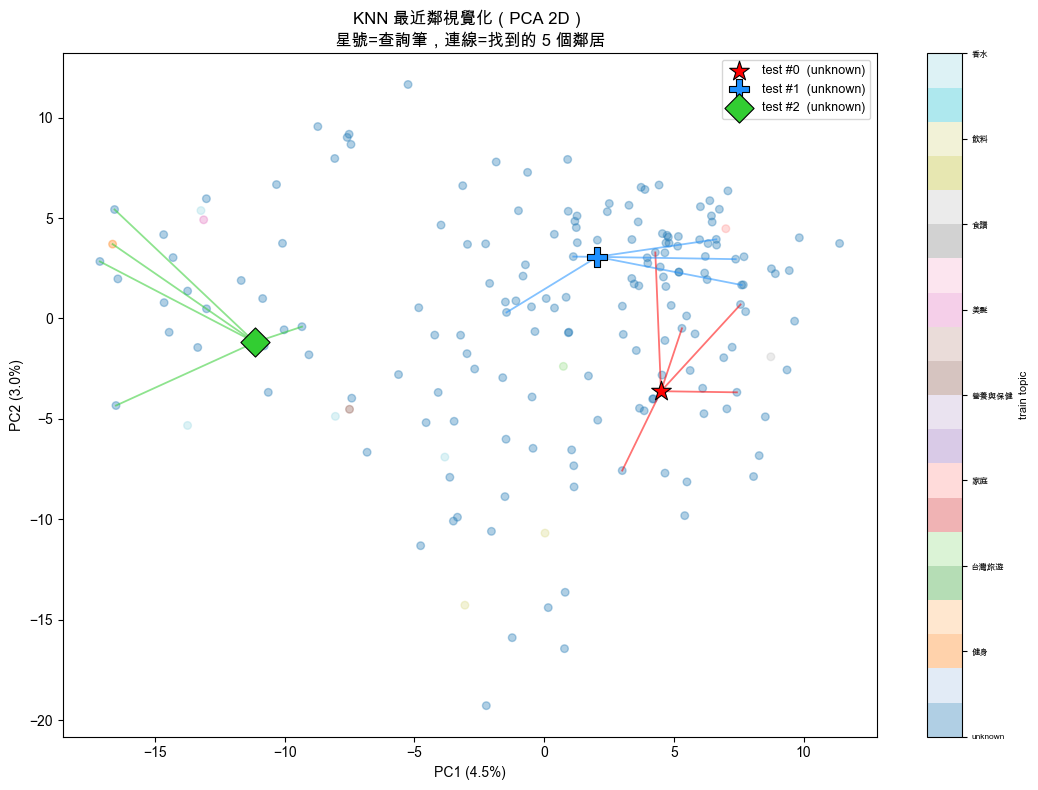

已儲存：../data/output/knn_viz.png


In [119]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams['font.family'] = 'Arial Unicode MS'

# ── 1. 找 test 全部 45 筆的 K=5 最近鄰 ──
dist_test, idx_test = knn.kneighbors(get_X(test_df))

info_cols = ['best_topic_labels', 'duration', 'AI業配判定']

print('=== Test 前 3 筆的最近鄰分析 ===')
for i in range(3):
    print(f'\n【查詢筆 #{i}】')
    print({c: test_df[c].iloc[i] for c in info_cols})
    print('  鄰居：')
    for rank, j in enumerate(idx_test[i]):
        info = {c: train_df[c].iloc[j] for c in info_cols}
        print(f'  [{rank+1}] dist={dist_test[i][rank]:.4f}  {info}')

# ── 2. PCA 2D 散點圖 + 連線 ──
pca_viz = PCA(n_components=2, random_state=42)
X_train_2d = pca_viz.fit_transform(X_train)
X_test3_2d = pca_viz.transform(get_X(test_df.iloc[:3]))

topics    = sorted(train_df['best_topic_labels'].fillna('unknown').unique())
topic_idx = {t: i for i, t in enumerate(topics)}
train_c   = [topic_idx[t] for t in train_df['best_topic_labels'].fillna('unknown')]

fig, ax = plt.subplots(figsize=(11, 8))

# 全部 train 點，顏色代表 topic
sc = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                c=train_c, cmap='tab20', alpha=0.35, s=30)

# test 前 3 筆（星號）+ 連線到各自 5 個鄰居
query_colors  = ['red', 'dodgerblue', 'limegreen']
query_markers = ['*', 'P', 'D']
for i in range(3):
    label = test_df['best_topic_labels'].fillna('unknown').iloc[i]
    ax.scatter(X_test3_2d[i, 0], X_test3_2d[i, 1],
               c=query_colors[i], s=220, marker=query_markers[i],
               edgecolors='black', linewidths=0.8, zorder=5,
               label=f'test #{i}  ({label})')
    for j in idx_test[i]:
        ax.plot([X_test3_2d[i, 0], X_train_2d[j, 0]],
                [X_test3_2d[i, 1], X_train_2d[j, 1]],
                color=query_colors[i], alpha=0.55, linewidth=1.3, zorder=4)

cbar = plt.colorbar(sc, ax=ax, ticks=range(len(topics)))
cbar.ax.set_yticklabels([t[:18] for t in topics], fontsize=6)
cbar.set_label('train topic', fontsize=8)

ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%})')
ax.set_title('KNN 最近鄰視覺化（PCA 2D）\n星號=查詢筆，連線=找到的 5 個鄰居')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()

viz_path = OUTPUT / 'knn_viz.png'
plt.savefig(viz_path, dpi=150)
plt.show()
print(f'已儲存：{viz_path}')